<a href="https://colab.research.google.com/github/gupaulasan/portfolio/blob/1b2aba61305d6db0d8e5907e2197f7eef707cc3e/Electric%20Bikes%20Reviews/electric_motorcycles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Predicting e-motorcycles ownership based on user ratings

by [Gustavo Santos](https://www.linkedin.com/in/gustavopsantos/)

This project aims to predict whether an electric moped user review comes from an owner or not using 2 different Machine Learning models. This project was part of my [Data Scientist Associate Certification](https://www.datacamp.com/certificate/DSA0013508028257) exam.

## What you will find in this project
1. [Data exploration](#data-exploration)
2. [Data cleaning](#data-cleaning)
3. [Data analysis](#data-analysis)

## Background
* EMO is a manufacturer of electric mopeds
* EMO launched its first electric moped in India in 2019
* The Product team has been asking website users to rate the motorcycles
* Ratings from owners help the product team to improve the quality of the motorcycles
* Ratings from non-owners help the product team add new features. They hope the new features will increase the number of new customers
* The product team wants to extend the survey. But, they want to be sure they can predict whether the ratings came from owners or non-owners.

## Data
The [dataset](electric_bike_ratings_2212.csv) contains  rating information about mopeds collected by the product team.

|Column Name| Criteria|
|---|---|
|owned| **Nominal**. Whether the reviewer owns the moped (1) or not (0).|
|make_model| **Nominal**. The make and model of the bike, one of six possible values (Nielah-Eyden, Nielah-Keetra, Lunna-Keetra, Hoang-Keetra, Lunna-Eyden, Hoang-Eyden).|
|review_month| **Nominal**. The month the review was given in English short format (Jan, Feb, Mar, Apr etc.).|
|web_browser| **Nominal**. Web browser used by the user leaving the review, one of Chrome, IE, Firefox, Safari, Android, Opera.|
|reviewer_age| **Discrete**. Age of the user leaving the review. Integer values from 16.|
|primary_use| **Nominal**. The main reason the user reports that they use the bike for. One of Commuting or Leisure.|
|value_for_money| **Discrete**. Rating given by the user on value for money of the bike. Rating from 1 to 10.|
|overall_rating| **Continuous**. Total rating score after combining multiple rating scores. Continuous values from 0 to 25 are possible.|

<a id='data-exploration'></a>
## Data Exploration

### Data description
As shown bellow, the dataset contains **1500 rows and 8 columns**  with missing values before cleaning. After cleaning and validating all the columns, the columns and criteria are as follow:
* **owned**: Same as description with no missing values, 2 unique values
* **make_model:** Same as description with no missing values
* **review_month:** Got the month from the string in the values. No missing values
* **web_browser**: 150 missing values, missing values were replaced with 'unknown'
* **reviewer_age:** 105 missing values, originally set to the string `'-'`, missing values were replaced with the mean age. Converted into numerical type
* **primary_use:** Same as description without missing values
* **value_for_money:** No missing values. 10 unique values. Converted into numerical type
* **overall_rating:** Same as description without missing values.

In [67]:
#Importing Packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
#Read csv file
df = pd.read_csv('electric_bike_ratings_2212.csv')

In [69]:
#Check info
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   owned            1500 non-null   int64  
 1   make_model       1500 non-null   object 
 2   review_month     1500 non-null   object 
 3   web_browser      1350 non-null   object 
 4   reviewer_age     1500 non-null   object 
 5   primary_use      1500 non-null   object 
 6   value_for_money  1500 non-null   object 
 7   overall_rating   1500 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 93.9+ KB


None

Comparing the data description and the DataFrame info, it is possible to get some insights that should be further investigated:
* Even though the `reviewer_age` column should be a numeric value, it is shown as an object column.
* The `value_for_money` column should also be a numeric value, but instead it is an object column.


In [70]:
print('Na values: \n' + str(df.isna().sum()) +'\n')

Na values: 
owned                0
make_model           0
review_month         0
web_browser        150
reviewer_age         0
primary_use          0
value_for_money      0
overall_rating       0
dtype: int64



Column `web_browser` has missing values

In [71]:
df.head()

,owned,make_model,review_month,web_browser,reviewer_age,primary_use,value_for_money,overall_rating
0,1,Nielah-Eyden,Oct,Chrome,23,Commuting,5/10,18.62
1,0,Nielah-Keetra,Jun,NaN,24,Commuting,4/10,15.55
2,0,Lunna-Keetra,23-Oct,Chrome,28,Commuting,5/10,12.76
3,1,Hoang-Keetra,07-Nov,IE,41,Leisure,5/10,17.07
4,1,Lunna-Keetra,16-Sep,Chrome,33,Leisure,5/10,12.29


Looking at the data above, these are the next steps:
- There are values in `review_month` that also include the date, The last 3 digits are the actual month;
- `web_browser` missing values are NaN values;
- `value_for_money` is shown as X/10, that why it is an object column;

### Validate categorical values

From the data description, it is expected to have a specific number of unique values for each categorical column. The expected values are:

*These values consider that the only column with missing values is the web_browser one, as shown before*

* **owned** - 2 unique values (1 and 0)
* **make_model** - 6 unique values (The 6 possible Make-Model combinations)
* **review_month** - 12 unique values (The 12 months in a year)
* **web_browser** - 7 unique values (6 possible browsers + `null`)
* **primary_use** - 2 unique values (Commuting and Leisure)
* **value_for_money** - 10 unique values (from 1/10 to 10/10)

In [72]:
cat_cols = ['owned', 'make_model', 'review_month', 'web_browser','primary_use','value_for_money']

for col in cat_cols:
    print(f'Unique {col}: ' + str(len(pd.unique(df[col]))))

Unique owned: 2
Unique make_model: 6
Unique review_month: 332
Unique web_browser: 7
Unique primary_use: 2
Unique value_for_money: 10


<a id='data-cleaning'></a>
## Data Cleaning

### Cleaning Month data
As discussed before, the amount of unique values in the categorical columns does not correspond to the expected amount in a column. Therefore, it is necessary to understand and act in a solution for these discrepancies. Here is the plan:
1. Check some of the `df.review_month` column in the `df.head()` output, shown before;
2. Observe that some of the data in this column present Date-Mon format and some only Mon format;
3. Extract the last 3 characters from the input as it shows the month abreviation, as described in the data description table;
4. Check if it worked, it will have worked if `review_month` unique count ≤ 12).


In [73]:
#Create new column with month abbreviation: review_month_abbr
df['review_month'] = df.review_month.str[-3:]
display(df.review_month.unique())

#Check amount of unique values
print('Unique review_month: ' + str(len(pd.unique(df['review_month']))))

array(['Oct', 'Jun', 'Nov', 'Sep', 'Aug', 'Mar', 'Jul', 'Apr', 'Dec',
       'Feb', 'Jan', 'May'], dtype=object)

Unique review_month: 12


### Cleaning web_browser missing data
For the `web_browser` column to match the data description, the `null` values will be replaced with 'unknown'

In [74]:
df['web_browser'] = df.web_browser.fillna('unknown')
df.web_browser.unique()

array(['Chrome', 'unknown', 'IE', 'Firefox', 'Safari', 'Android', 'Opera'],
      dtype=object)

### Validate numerical values

From the data description, it is expected that the numerical data columns match specific conditions.

* **reviewer_age** - numerical values only, minimum value >= 16 or missing data
* **value_for_money** - minimum value >= 1, maximum value <= 10 or missing data
* **overall_rating** - minimum value >= 0, maximum value <= 25 or missing data

In [75]:
num_cols = ['reviewer_age','value_for_money','overall_rating']
for col in num_cols:
    print(str(df[col].describe()),'\n')

count     1500
unique      36
top          -
freq       105
Name: reviewer_age, dtype: object 

count     1500
unique      10
top       5/10
freq       387
Name: value_for_money, dtype: object 

count    1500.000000
mean       17.138907
std         2.445566
min        11.690000
25%        15.320000
50%        18.240000
75%        18.840000
max        22.760000
Name: overall_rating, dtype: float64 



### Cleaning numerical data
The output shown above shows that there are two major problems with the data in these colums:
1. The `reviewer_age` column is not in the correct data type, it currently an `object` dtype and it should be a `int`
     1. This happens because there are 105 entries that are `'-'`;
     2. These values are going to be set to the columns avarage value
     3. Round the values to the previous integer, because there no age should be decimal
2. The `value_for_money` column is currently shown in a X/10 format, which makes managing and manipulating the data harder

In [89]:
#Replace '-' to np.nan
df.replace('-',np.nan,inplace=True)
#Change data type to numerical
df['reviewer_age'] = df.reviewer_age.astype('float')
#Replace np.nan to the mean value 
df.replace(np.nan,df['reviewer_age'].mean(),inplace=True)
#Convert age to the previous integer
df['reviewer_age'] = df.reviewer_age.astype('int')
print('Checking if it worked')
df.reviewer_age.describe()

Checking if it worked


count    1500.000000
mean       32.556000
std         9.876769
min        16.000000
25%        24.000000
50%        32.000000
75%        41.000000
max        50.000000
Name: reviewer_age, dtype: float64

### Value_for_money approach
As it is not possible to convert a string in the format 'X/10' directly to a float, this problem will demand an out of the box approach.
1. The algorithm will split the string into two parts (numerator and denominator)
2. The numerator will be used as the new value

In [77]:
df['value_for_money'] = df['value_for_money'].apply(lambda x: (int(x.split('/')[0])))

In [78]:
df.value_for_money.describe()

count    1500.000000
mean        4.977333
std         1.486257
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: value_for_money, dtype: float64

### Final check
Now, it is necessary to check if the columns are in the correct dtype and finish the cleaning phase. Is is necessary to have 1500 non-null entries.

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   owned            1500 non-null   int64  
 1   make_model       1500 non-null   object 
 2   review_month     1500 non-null   object 
 3   web_browser      1500 non-null   object 
 4   reviewer_age     1500 non-null   int32  
 5   primary_use      1500 non-null   object 
 6   value_for_money  1500 non-null   int64  
 7   overall_rating   1500 non-null   float64
dtypes: float64(1), int32(1), int64(2), object(4)
memory usage: 88.0+ KB


<a id='data-analysis'></a>
## Data Analysis

From **Graph 1 | The Count of Owned**, most reviews come from people that own a moped. There is not a balance between the categories of the owned variable

In [80]:
sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('colorblind')

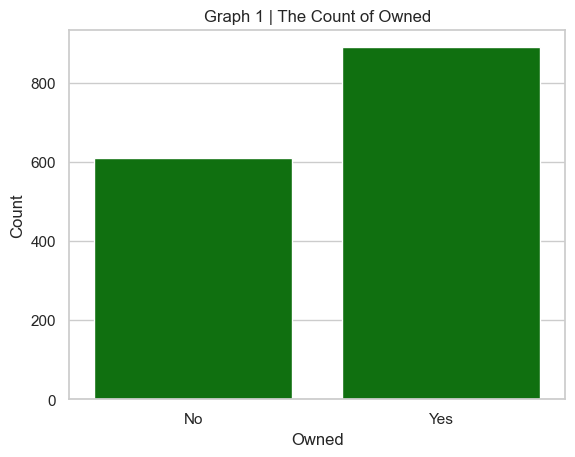

In [81]:
ax1 = sns.countplot(data=df, 
                   x='owned',
                   color='green')\
        .set(title="Graph 1 | The Count of Owned",
             xticklabels=['No','Yes'],
            xlabel='Owned',
            ylabel='Count')

## Task 3
From **Graph 2 | Overall Rating Distribution**, the overall rating values vary from 11 up to 22. There is a high count of values that fall inbetween **18.5 and 19.5**, this interval being the most common one, followed by the ranges from **14.5 up to 15.5** and **17.5 to 18.5**

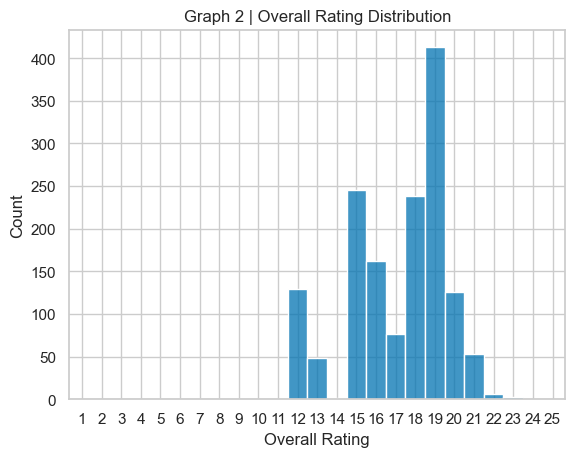

In [82]:
ax2 = sns.histplot(x='overall_rating',
                  data=df,
                  bins=np.arange(1.5,25.5,1)
                  )\
    .set(title='Graph 2 | Overall Rating Distribution',
        xlabel='Overall Rating',
        xticks=np.arange(1,26,1))

## Task 4
From **Graph 3 | Relationship Between Ownership and Overal Rating**, all the quartiles are set at a greater overall rating in the owners reviews when compared to the reviews of people that do not own a moped. 

A good measure of the data comparisson is the median (the line crossing in the middle of the box) and the height of the boxes (which shows the distance between the 1st and 3rd quartile. In this case, it is possible to observe that the median of reviews coming from people that own a moped is higher than the 3rd quartile of people that do not own a moped.

With what was stated above, it is possible to get two insights from the graph. People who own a moped tend to have aa greater overall rating of the product when compared to people that do not own a moped. Furthermore, the opinions in from people that own a moped differ less than the opinion of people who don't own one.

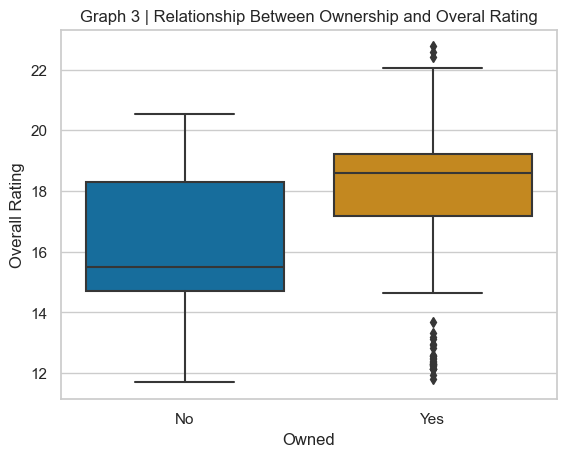

In [83]:
ax3 = sns.boxplot(data=df, 
                  x='owned',
                  y='overall_rating'
                 )\
        .set(title='Graph 3 | Relationship Between Ownership and Overal Rating',
            xlabel='Owned',
            xticklabels=['No', 'Yes'],
            ylabel='Overall Rating'
            )

## Task 5
 Predicting whether a review came from an owner or not is a **classification problem** in machine learning

### Changes to modeling
In order to be able to fit the data in a model, it is necessary to have the data as numerical data. The following changes are necessary:
* All categorical columns are converted to numeric variables;
* Split data into features and 

In [84]:
# Importing packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [85]:
features = df.drop('owned', axis=1)

In [86]:
#Convert to numeric and split data
X = pd.get_dummies(features, columns=['make_model', 'review_month', 'web_browser','primary_use'], drop_first=True)
y = df['owned']

In [87]:
#Split data into 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2710, stratify=y )

## Task 6
Baseline model - K Neighbors Classifier model

In [88]:
# Fitting KNeighbors
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_predict = knn.predict(X_test)

AttributeError: 'Flags' object has no attribute 'c_contiguous'

## Task 7
Comparisson model - Random  Forrest Classifier model

In [ ]:
# Fitting Random Forest
rand_for_class = RandomForestClassifier()
rand_for_class.fit(X_train, y_train)
rand_for_class_predict = rand_for_class.predict(X_test)

## Task 8
I am choosing **K-Neighbors Classifier** as a baseline model because it is simple to use, train and evaluate. The comparisson model chosen is the **Random Forest Classifier** because it is able to observe more complex relationships between the features, which could lead to a better performance

## Task 9
I am choosing **Accuracy Score** as my performance evaluator because it is a simple to understand variable, while still a good way to check the performance of a model

### Evaluating KNeighbors Model

In [ ]:
knn_acc = accuracy_score(y_test, knn_predict)
print(f'KNN accuracy score: {knn_acc}')

KNN accuracy score: 0.7066666666666667


### Evaluating Random Forest Model

In [ ]:
rand_for_class_acc = accuracy_score(y_test, rand_for_class_predict)
print(f'Random Forest accuracy score: {rand_for_class_acc}')

Random Forest accuracy score: 0.7266666666666667


## Task 10
A bigger accuracy score means a better perfomance. the accuracy score could be transformed into a percentage of right predictions made by the model.

This mean the **Random Forest Model** had a better performance when compared to the **K-Neighbors model** for predicting wheter or not a review comes from a owner of the products.